# Stiffness Detection in Integrators

This notebook demonstrates:
1. The **van der Pol oscillator** — comparing explicit (RK12, BS3) and implicit (BE2, Rosenbrock) methods
2. The **Prothero-Robinson problem** — a clean test case where stiffness is decoupled from solution complexity
3. **Stiffness detection** from BS3 stage differences
4. **Auto-switching** between BS3 and Rosenbrock

In [1]:
%pip install -q git+https://github.com/adrs0049/ode-integrate.git

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from integrate.rk12 import rk2_adaptive
from integrate.rk23 import rk3_adaptive
from integrate.bs3 import bs3_adaptive
from integrate.be2 import be2_adaptive
from integrate.rosenbrock23 import ros2_adaptive
from integrate.ode23s import ode23s

## 1. Van der Pol Oscillator

$$u_1' = u_2, \qquad u_2' = \frac{(1-u_1^2)u_2 - u_1}{\varepsilon}$$

For small $\varepsilon$ the system develops fast transients (boundary layers) separated by slow phases. Explicit methods must take tiny steps during the fast transients for **stability**, not accuracy.

In [3]:
eps = 1e-2

def f_vdp(t, y):
    return np.array([
        y[1],
        ((1. - y[0]**2) * y[1] - y[0]) / eps
    ])

ic = np.array([2.0, 0.])
t0, te = 0.0, 2.0
tols = dict(atol=1e-6, rtol=1e-6)

print('RK12:')
d_rk12 = rk2_adaptive(ic, f_vdp, te=te, stepmax=500000, k0=0.1, **tols)

print('\nBS3:')
d_bs3, diag_bs3 = bs3_adaptive(ic, f_vdp, te=te, stepmax=500000, k0=0.1, verbose=True, **tols)

print('\nRosenbrock:')
d_ros, diag_ros = ros2_adaptive(ic, f_vdp, te=te, k0=0.1, verbose=True, stepmax=50000, **tols)

print('\node23s (auto-switch):')
d_auto, diag_auto = ode23s(ic, f_vdp, te=te, stepmax=500000, k0=0.1, verbose=True, **tols)

RK12:
Explicit RK2: Success!
Accepted steps =  22146  Rejected steps =  10

BS3:


BS3 (Bogacki-Shampine): Success!
Accepted steps = 1237  Rejected steps = 20
Function evaluations = 3772.
Stiffness detected: False  (counter=0)

Rosenbrock:
Rosenbrock 2(3) (L-stable, Shampine): Success!
Accepted steps = 3112  Rejected steps = 220
Function evaluations = 10529.
Jacobian evaluations = 266.
LU solves = 9996.

ode23s (auto-switch):
Auto-switch BS3/Rosenbrock: Success!
Accepted steps = 1237  Rejected steps = 20
Function evaluations = 3772.
Switch events:
  (none)


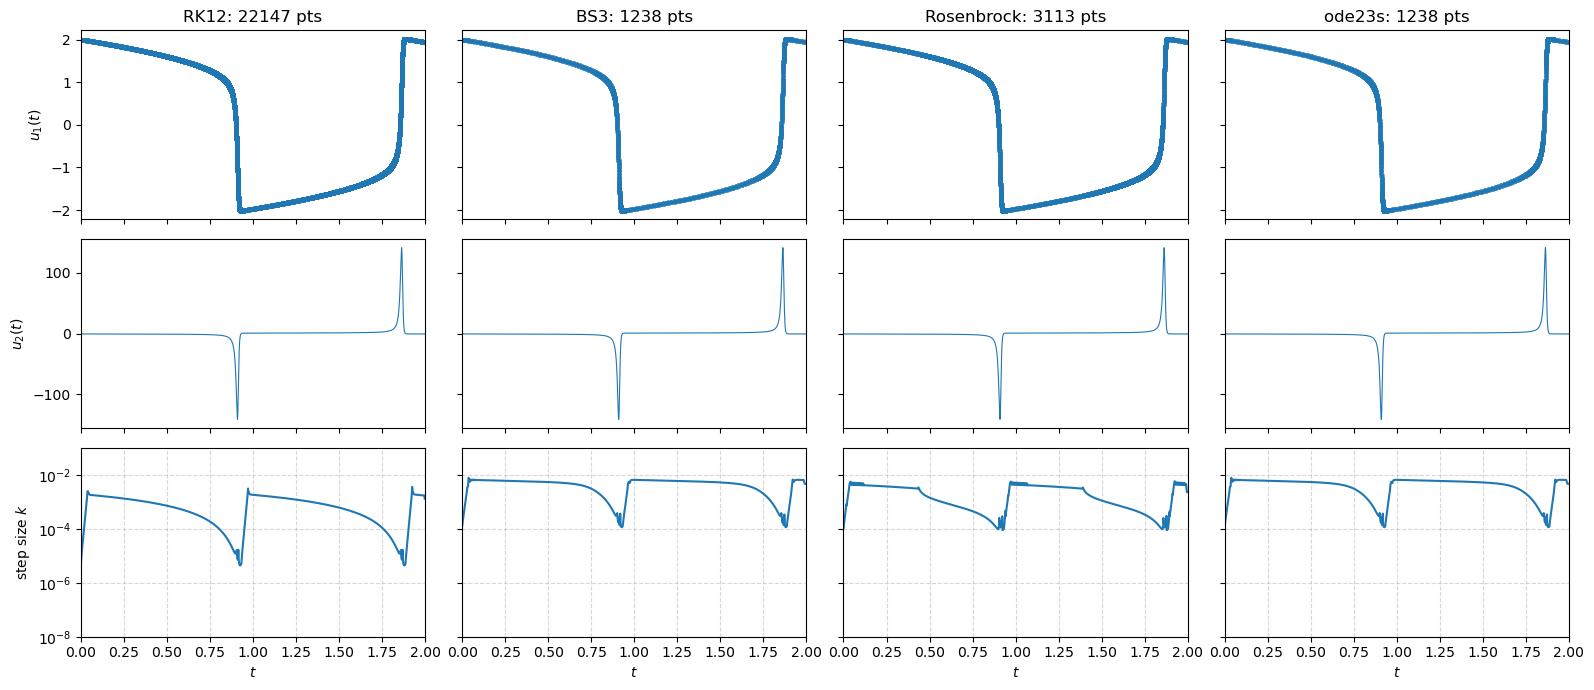

In [4]:
datasets = [
    (d_rk12, 'RK12'),
    (d_bs3,  'BS3'),
    (d_ros,  'Rosenbrock'),
    (d_auto, 'ode23s'),
]

fig, axs = plt.subplots(3, len(datasets), figsize=(4*len(datasets), 7),
                        sharey='row', sharex=True)
ms = 3

for col, (data, name) in enumerate(datasets):
    ts = data['t']
    un = data['u']
    ks = np.diff(ts)
    ks = np.hstack((ks, ks[-1]))

    axs[0, col].set_title(f'{name}: {ts.size} pts')
    axs[0, col].plot(ts, un[:, 0], marker='x', markersize=ms, linewidth=0.8)
    axs[1, col].plot(ts, un[:, 1], linewidth=0.8)
    axs[2, col].semilogy(ts, ks)
    axs[2, col].set_xlabel('$t$')
    axs[2, col].grid(ls='--', alpha=0.5)

axs[0, 0].set_ylabel('$u_1(t)$')
axs[1, 0].set_ylabel('$u_2(t)$')
axs[2, 0].set_ylabel('step size $k$')
axs[2, 0].set_ylim([1e-8, 1e-1])

for ax in axs.flatten():
    ax.set_xlim([t0, te])

fig.tight_layout()
plt.show()

## 2. The Prothero-Robinson Problem: What Stiffness Really Is

$$u' = \lambda(u - \cos t) - \sin t, \qquad u(0) = 1$$

The exact solution is $u(t) = \cos(t)$ for **any** $\lambda$. The solution is the same smooth cosine regardless of whether $\lambda = -1$ or $\lambda = -10^6$.

### The key distinction: $h_{\text{accuracy}}$ vs $h_{\text{stability}}$

An adaptive integrator chooses its step size $h$ to control local truncation error. Call this the **accuracy-limited step size** $h_{\text{accuracy}}$. Since $u(t) = \cos(t)$ is the same smooth function for all $\lambda$, the accuracy requirement is essentially **independent of $\lambda$**.

But an explicit method also has a **stability-limited step size** $h_{\text{stability}} \lesssim 2/|\lambda|$. Any step larger than this causes the numerical solution to blow up, regardless of how accurate it would be.

**A problem is stiff when $h_{\text{accuracy}} \gg h_{\text{stability}}$.**

The integrator *could* take large steps and still get an accurate answer, but stability forces it to take tiny steps instead. The computational effort is wasted on maintaining stability, not on resolving the solution.

We demonstrate this with two values of $\lambda$:

| | $\lambda = -10$ (non-stiff) | $\lambda = -10^4$ (stiff) |
|---|---|---|
| Exact solution | $\cos(t)$ | $\cos(t)$ (identical!) |
| $h_{\text{accuracy}}$ | $\sim 10^{-1}$ | $\sim 10^{-1}$ (same smooth solution) |
| $h_{\text{stability}}$ (BS3) | $\sim 0.25$ | $\sim 2.5 \times 10^{-4}$ |
| Stiff? | No: $h_{\text{acc}} \approx h_{\text{stab}}$ | **Yes**: $h_{\text{acc}} / h_{\text{stab}} \approx 400$ |

In [5]:
u0 = np.array([1.0])
exact = lambda t: np.cos(t)
tols_pr = dict(atol=1e-4, rtol=1e-4)

# --- Non-stiff case: lambda = -10 ---
lam_ns = -10

def f_pr_ns(t, y):
    return lam_ns * (y - np.cos(t)) - np.sin(t)

def jac_pr_ns(t, y):
    return np.array([[lam_ns]])

print('=== lambda = -10 (non-stiff) ===')
print('BS3:')
pr_ns_bs3, dg_ns_bs3 = bs3_adaptive(u0, f_pr_ns, te=10.0, stepmax=500000, verbose=True, **tols_pr)
print('Rosenbrock:')
pr_ns_ros, dg_ns_ros = ros2_adaptive(u0, f_pr_ns, te=10.0, verbose=True, jac=jac_pr_ns, **tols_pr)

# --- Stiff case: lambda = -1e4 ---
lam_s = -1e4

def f_pr_s(t, y):
    return lam_s * (y - np.cos(t)) - np.sin(t)

def jac_pr_s(t, y):
    return np.array([[lam_s]])

print('\n=== lambda = -1e4 (stiff) ===')
print('BS3:')
pr_s_bs3, dg_s_bs3 = bs3_adaptive(u0, f_pr_s, te=10.0, stepmax=500000, verbose=True, **tols_pr)
print('Rosenbrock:')
pr_s_ros, dg_s_ros = ros2_adaptive(u0, f_pr_s, te=10.0, stepmax=50000, verbose=True, jac=jac_pr_s, **tols_pr)

print('\node23s (stiff):')
pr_s_auto, dg_s_auto = ode23s(u0, f_pr_s, te=10.0, stepmax=500000, verbose=True, jac=jac_pr_s, **tols_pr)

=== lambda = -10 (non-stiff) ===
BS3:
BS3 (Bogacki-Shampine): Success!
Accepted steps = 97  Rejected steps = 9
Function evaluations = 319.
Stiffness detected: False  (counter=0)
Rosenbrock:
Rosenbrock 2(3) (L-stable, Shampine): Success!
Accepted steps = 155  Rejected steps = 8
Function evaluations = 490.
Jacobian evaluations = 20.
LU solves = 489.

=== lambda = -1e4 (stiff) ===
BS3:


BS3 (Bogacki-Shampine): Success!
Accepted steps = 39793  Rejected steps = 6
Function evaluations = 119398.
Stiffness detected: True  (counter=19)
Rosenbrock:
Rosenbrock 2(3) (L-stable, Shampine): Success!
Accepted steps = 388  Rejected steps = 12
Function evaluations = 1201.
Jacobian evaluations = 25.
LU solves = 1200.

ode23s (stiff):
Auto-switch BS3/Rosenbrock: Success!
Accepted steps = 405  Rejected steps = 18
Function evaluations = 1282.
Jacobian evaluations = 27.
LU solves = 1206.
Switch events:
  t=0.004858: BS3 -> Rosenbrock


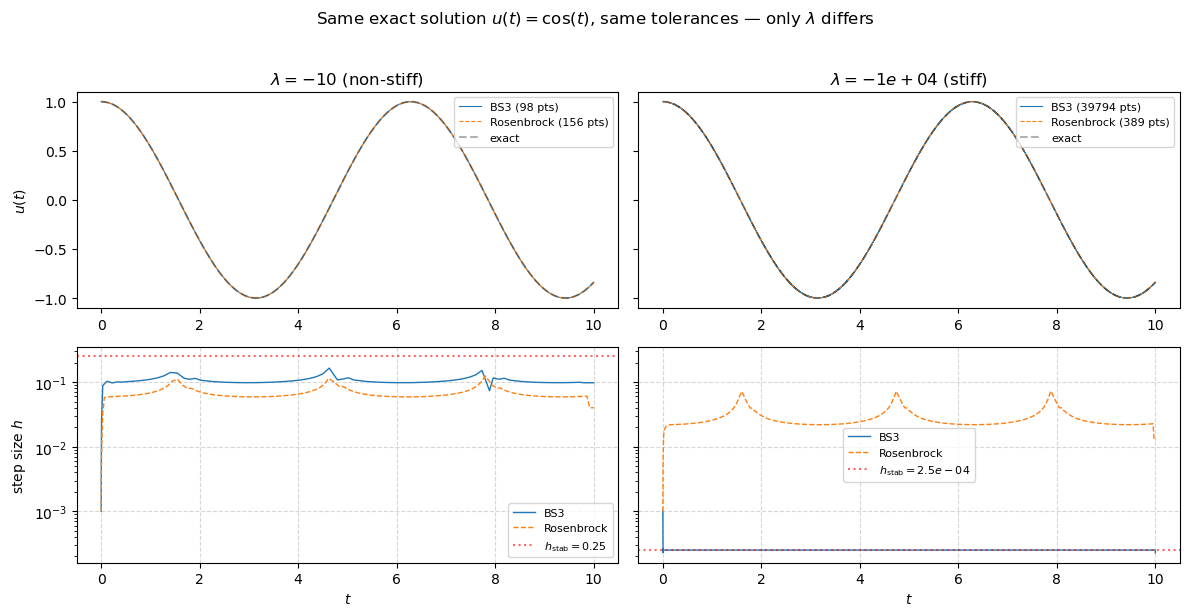

In [6]:
t_ref = np.linspace(0, 10, 1000)

fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharey='row')

# --- Left column: lambda = -10 (non-stiff) ---
for data, name, ls in [(pr_ns_bs3, 'BS3', '-'), (pr_ns_ros, 'Rosenbrock', '--')]:
    ts = data['t']
    un = data['u']
    ks = np.diff(ts)
    ks = np.hstack((ks, ks[-1]))
    axs[0, 0].plot(ts, un[:, 0], ls, linewidth=0.8, label=f'{name} ({ts.size} pts)')
    axs[1, 0].semilogy(ts, ks, ls, label=name, linewidth=1.0)

axs[0, 0].plot(t_ref, exact(t_ref), 'k--', alpha=0.3, label='exact')
axs[0, 0].set_title(f'$\\lambda = {lam_ns}$ (non-stiff)')
axs[0, 0].legend(fontsize=8)
axs[1, 0].set_xlabel('$t$')
axs[1, 0].grid(ls='--', alpha=0.5)
axs[1, 0].axhline(2.5/abs(lam_ns), color='r', ls=':', alpha=0.6, label=f'$h_{{\\mathrm{{stab}}}} = {2.5/abs(lam_ns):.2f}$')
axs[1, 0].legend(fontsize=8)

# --- Right column: lambda = -1e4 (stiff) ---
for data, name, ls in [(pr_s_bs3, 'BS3', '-'), (pr_s_ros, 'Rosenbrock', '--')]:
    ts = data['t']
    un = data['u']
    ks = np.diff(ts)
    ks = np.hstack((ks, ks[-1]))
    axs[0, 1].plot(ts, un[:, 0], ls, linewidth=0.8, label=f'{name} ({ts.size} pts)')
    axs[1, 1].semilogy(ts, ks, ls, label=name, linewidth=1.0)

axs[0, 1].plot(t_ref, exact(t_ref), 'k--', alpha=0.3, label='exact')
axs[0, 1].set_title(f'$\\lambda = {lam_s:.0e}$ (stiff)')
axs[0, 1].legend(fontsize=8)
axs[1, 1].set_xlabel('$t$')
axs[1, 1].grid(ls='--', alpha=0.5)
axs[1, 1].axhline(2.5/abs(lam_s), color='r', ls=':', alpha=0.6, label=f'$h_{{\\mathrm{{stab}}}} = {2.5/abs(lam_s):.1e}$')
axs[1, 1].legend(fontsize=8)

axs[0, 0].set_ylabel('$u(t)$')
axs[1, 0].set_ylabel('step size $h$')

fig.suptitle('Same exact solution $u(t) = \\cos(t)$, same tolerances — only $\\lambda$ differs',
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

### What the plots show

**Left column** ($\lambda = -10$): BS3 and Rosenbrock take a comparable number of steps. The step-size plot shows both methods choosing $h$ based on accuracy — they hover around the same level. The stability boundary $h_{\text{stab}} = 0.25$ is above the accuracy-limited step size, so stability is not the bottleneck. The problem is non-stiff.

**Right column** ($\lambda = -10^4$): The exact solution is identical, but BS3 is forced to take orders of magnitude more steps. Its step size is pinned near $h_{\text{stab}} = 2.5 \times 10^{-4}$ — the stability boundary, not the accuracy requirement. Meanwhile Rosenbrock (L-stable) ignores the stability constraint entirely and takes the same large accuracy-limited steps as in the non-stiff case.

This is the operational definition of stiffness: **the gap between $h_{\text{accuracy}}$ and $h_{\text{stability}}$**.

### Why BS3 takes *larger* steps than Rosenbrock on non-stiff problems

Notice that in the left column, BS3 actually uses a slightly larger step size than Rosenbrock — even though both methods produce order-2/3 pairs. The reason: **BS3 advances with its order-3 formula**, while Rosenbrock advances with its **order-2 formula**.

This is a deliberate design choice. The Rosenbrock 2(3) method (Shampine, 1997) uses:

- **Order-2 solution** for stepping (L-stable: $R(z) \to 0$ as $z \to -\infty$)
- **Order-3 embedded estimate** for error control (only A-stable)

It advances with the *lower*-order formula because L-stability requires $R(\infty) = 0$, which constrains the numerator degree of the stability function. The order-3 formula from the same stages doesn't satisfy this — it's A-stable ($|R(z)| \leq 1$) but not L-stable. For stiff problems, L-stability is essential: it ensures fast transients are actively **damped**, not merely bounded.

BS3 makes the opposite choice: it advances with the higher-order formula because stability isn't the concern for explicit methods (they have finite stability regions regardless).

This reflects a deeper trade-off. The cost of L-stability is **order efficiency**: for a given number of stages, the stability constraint consumes free parameters that would otherwise satisfy higher-order conditions. Specifically:

| Method type | Stages | Order | Stability |
|---|---|---|---|
| Explicit RK (BS3) | 4 (3 new via FSAL) | **3** | Finite region only |
| Rosenbrock (Shampine) | 3 linear solves | **2** (L-stable) / 3 (A-stable) | Left half-plane |
| Fully implicit RK (Radau IIA) | 3 coupled stages + Newton | **5** | L-stable |

Radau IIA achieves both high order *and* L-stability, but pays for it with Newton iterations on a coupled system — variable and expensive per step. Rosenbrock trades Newton iterations for predictable linear solves, and that trade-off costs order. This is why auto-switching makes sense: use the cheap, high-order explicit method when stability permits, and only pay the implicit tax when stiffness demands it.

## 3. Stiffness Detection from BS3 Stages

A problem is stiff when the spectral radius $\rho(J)$ of the Jacobian $J = \partial f / \partial y$ is large enough that $h \cdot \rho(J)$ exceeds the method's stability boundary. We need a cheap estimate of $\rho(J)$.

The BS3 method already computes $k_1 = f(t_n, y_n)$ and $k_4 = f(t_{n+1}, y_{n+1})$ (FSAL). Their difference is a finite-difference directional derivative of $f$ along the step:

$$k_4 - k_1 = f(t_{n+1}, y_{n+1}) - f(t_n, y_n) \approx J \cdot (y_{n+1} - y_n) + \frac{\partial f}{\partial t} \cdot h$$

Dividing by $\Delta y = y_{n+1} - y_n$ gives an estimate of the spectral radius:

$$|\lambda_{\mathrm{est}}| = \frac{\|k_4 - k_1\|}{\|y_{n+1} - y_n\|} \approx \rho(J)$$

This is essentially one step of power iteration applied to $J$, using the step direction as the iteration vector — at **zero extra cost** since $k_1$ and $k_4$ are already computed.

For the Prothero-Robinson problem, $f(t,y) = \lambda(y - \cos t) - \sin t$, so $J = \partial f / \partial y = \lambda$ and the true spectral radius is $|\lambda|$.

### Limitation: non-autonomous contamination

The estimate includes a $\partial f / \partial t$ contribution that doesn't cancel. For the Prothero-Robinson problem this is particularly severe: since the numerical solution closely tracks $\cos(t)$, the $J \cdot \Delta y$ term in the numerator nearly cancels with the $\Delta\cos$ contribution, leaving only the $\partial f/\partial t$ residual. The estimate degenerates to approximately $|\cot(t)|$ rather than $|\lambda|$, oscillating between $0$ and $\infty$ with period $\pi$. This is visible in the right panel below — the rapidly oscillating cloud of points bears no resemblance to the true $|\lambda| = 10^4$.

Despite this, the stiffness **detector** still works: near $t = n\pi$ the estimate spikes far above the stability threshold, and the persistence counter (threshold = 15) accumulates enough hits to trigger. The estimate is a poor pointwise approximation of $\rho(J)$, but a reliable enough binary signal for "stiff vs. non-stiff."

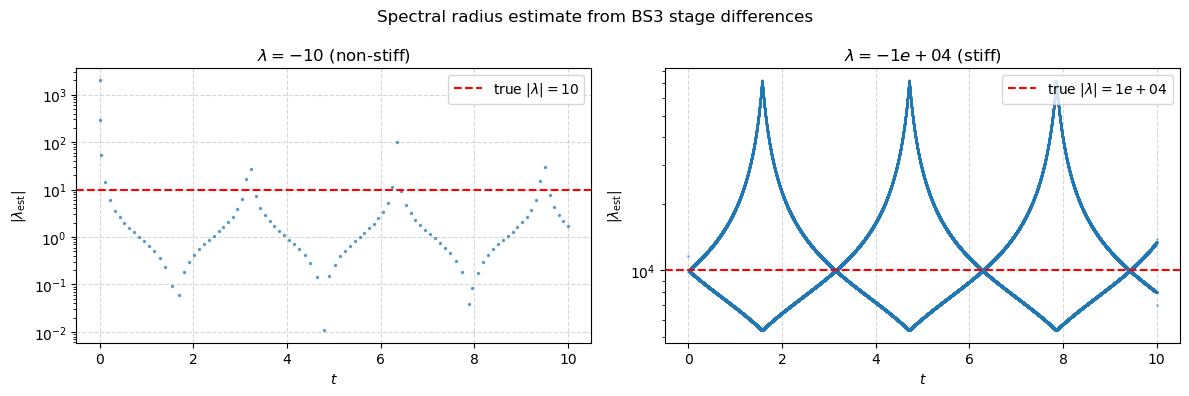

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Left: spectral radius estimate from BS3 on the non-stiff problem
sh_ns = dg_ns_bs3['spectral_history']
if sh_ns:
    t_sh = [x[0] for x in sh_ns]
    lam_est = [x[1] for x in sh_ns]
    axs[0].semilogy(t_sh, lam_est, '.', markersize=3, alpha=0.6)
    axs[0].axhline(abs(lam_ns), color='r', ls='--',
                   label=f'true $|\\lambda| = {abs(lam_ns)}$')
    axs[0].set_title(f'$\\lambda = {lam_ns}$ (non-stiff)')

sh_s = dg_s_bs3['spectral_history']
if sh_s:
    t_sh = [x[0] for x in sh_s]
    lam_est = [x[1] for x in sh_s]
    axs[1].semilogy(t_sh, lam_est, '.', markersize=2, alpha=0.4)
    axs[1].axhline(abs(lam_s), color='r', ls='--',
                   label=f'true $|\\lambda| = {abs(lam_s):.0e}$')
    axs[1].set_title(f'$\\lambda = {lam_s:.0e}$ (stiff)')

for ax in axs:
    ax.set_xlabel('$t$')
    ax.set_ylabel('$|\\lambda_{\\mathrm{est}}|$')
    ax.legend()
    ax.grid(ls='--', alpha=0.5)

fig.suptitle('Spectral radius estimate from BS3 stage differences', fontsize=12)
fig.tight_layout()
plt.show()